# Exploratory Data Analysis

**Project:** R2 - Bike Sharing Demand

**Team:** Angelina Bautista & Molly Scally

**Date:** 2-10-2026




## Table of Contents
1. Setup & Load Data
2. Data Quality Check
3. Target Variable Analysis
4. Feature Distributions
5. Correlation Analysis
6. Key Findings Summary



## 1. Setup & Load Data

In [38]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Settings
plt.style.use('seaborn-v0_8')
pd.set_option('display.max_columns', None)

print("✓ Libraries loaded!")

✓ Libraries loaded!


In [39]:
# Load your data
# TODO: Update the file path to your dataset
df = pd.read_csv('../data/raw/hour.csv')

df

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0000,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0000,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0000,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0000,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0000,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17374,17375,2012-12-31,1,1,12,19,0,1,1,2,0.26,0.2576,0.60,0.1642,11,108,119
17375,17376,2012-12-31,1,1,12,20,0,1,1,2,0.26,0.2576,0.60,0.1642,8,81,89
17376,17377,2012-12-31,1,1,12,21,0,1,1,1,0.26,0.2576,0.60,0.1642,7,83,90
17377,17378,2012-12-31,1,1,12,22,0,1,1,1,0.26,0.2727,0.56,0.1343,13,48,61


In [19]:
print(f'The dataset contains {df.shape[0]} rows and {df.shape[1]} columns.')

The dataset contains 17379 rows and 17 columns.


The dataset includes just over 17k rows. From the dataframe (and from the Kaggle data card) we know that the dataset spans a 2-year time period over the full years of 2011-2012. The columns include date/time features, aspects of the ambient environment, and bike usage numbers for each recorded hour. Each row corresponds to an hour of each day, thus we have data on 17,379 total hours. This is a little short of 2 years (17,520 + 24 for 2012's leap day = 17,544).  

The below code will do a quick check to see if hours without bike usage (where "cnt" = 0) were simply ommitted: 

In [31]:
print(f'there are {df.query("cnt == 0").shape[0]} instances where cnt = 0.')

there are 0 instances where cnt = 0.


So it's probably that the hours with zero rentals were just left out. The 165 missing hours could be important to address if we choose to do any serious time series modeling. The solution in that case would call for adding rows to complete the hourly grid, then imputing entries in the feature columns (e.g, in environment-related columns, forward-filling with the previous condition; placing zeroes in the count columns). We needn't worry about any of this until later.   

For EDA purposes, could further explore the missing rows by applying the grid to a copy of the original dataset. It might be interesting to see if they all occurred in big chunks or were randomly scattered over time. 

on-grid data has 17544 rows


<Axes: >

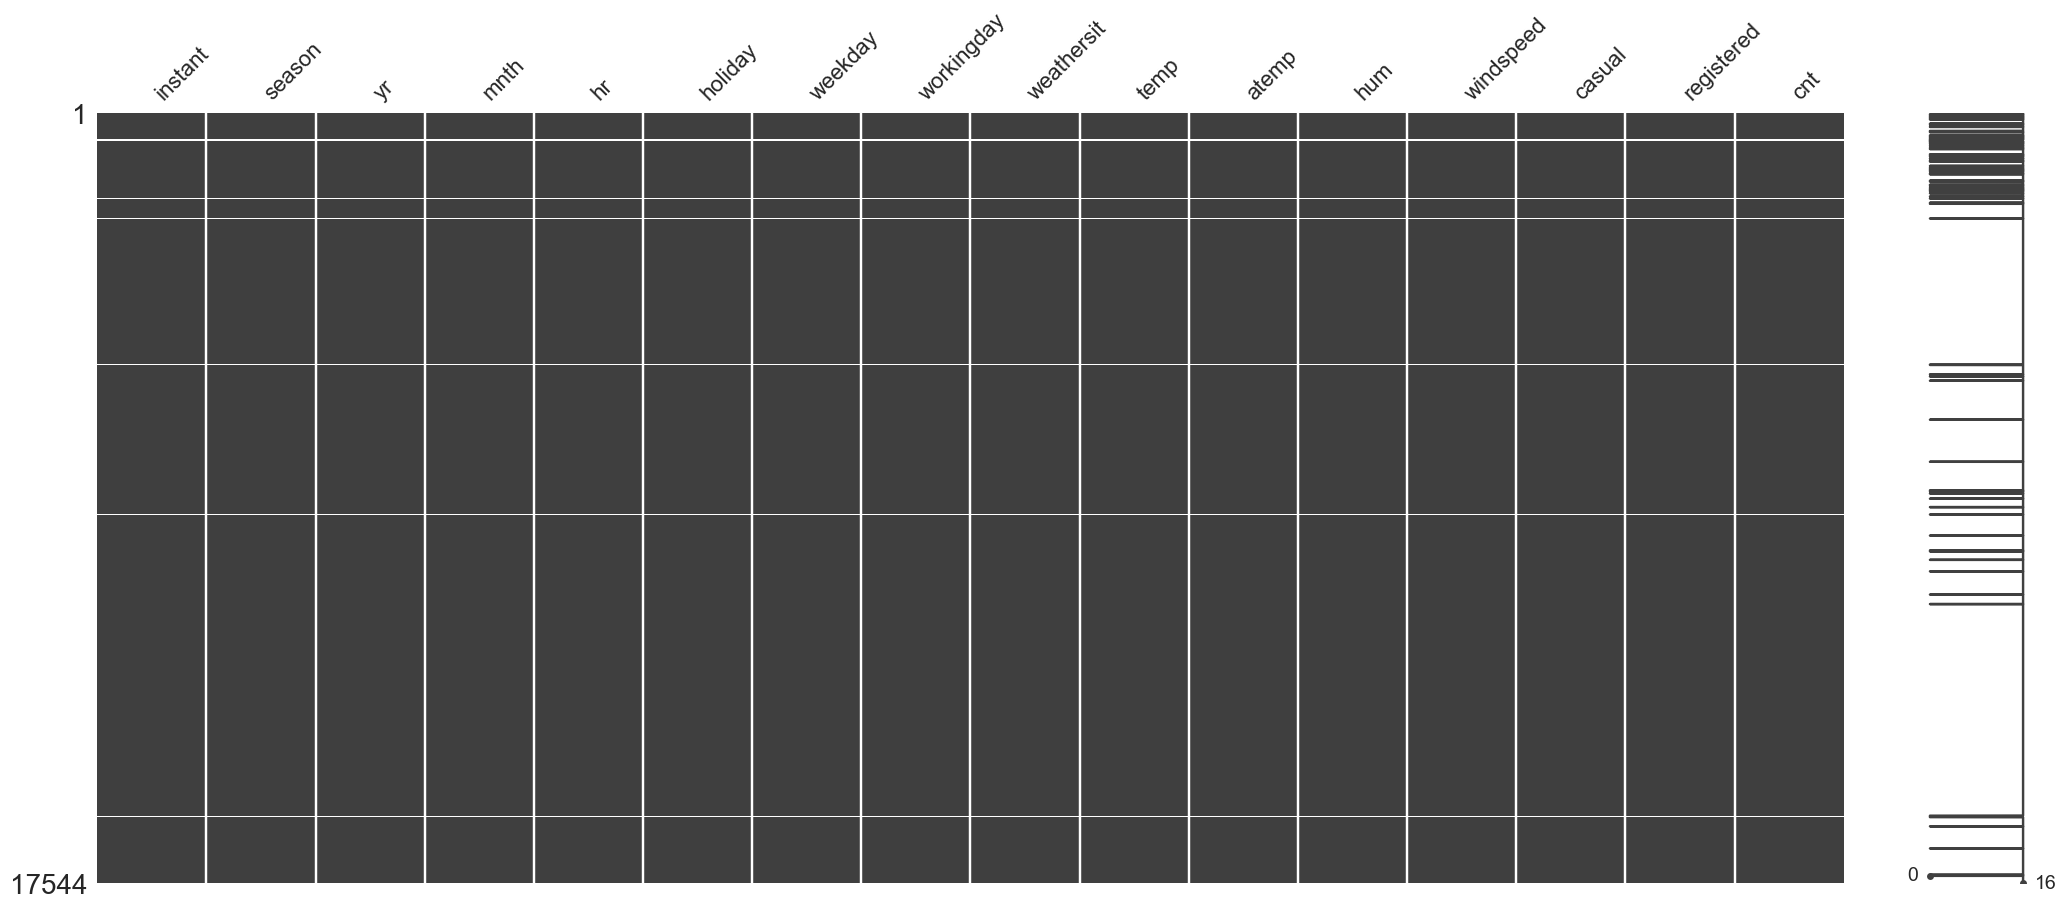

In [ ]:
df_full_grid = df.copy()  # make copy of the original dataset 

# convert date column to date type and add the time according to `hr`
df_full_grid['dteday'] = pd.to_datetime(df_full_grid['dteday']) + pd.to_timedelta(df_full_grid['hr'], unit='h')

# create full grid of times
grid = pd.date_range(start=df_full_grid['dteday'].min(), end=df_full_grid['dteday'].max(), freq='h')

# apply grid and new nan rows
df_full_grid = df_full_grid.set_index('dteday').reindex(grid)

print(f'on-grid data has {df_full_grid.shape[0]} rows')

import missingno as msno
msno.matrix(df_full_grid)

In [ ]:
for record in df_full_grid.index[df_full_grid['cnt'].isna()]:
    print(record)

2011-01-02 05:00:00
2011-01-03 02:00:00
2011-01-03 03:00:00
2011-01-04 03:00:00
2011-01-05 03:00:00
2011-01-06 03:00:00
2011-01-07 03:00:00
2011-01-11 03:00:00
2011-01-11 04:00:00
2011-01-12 03:00:00
2011-01-12 04:00:00
2011-01-14 04:00:00
2011-01-18 00:00:00
2011-01-18 01:00:00
2011-01-18 02:00:00
2011-01-18 03:00:00
2011-01-18 04:00:00
2011-01-18 05:00:00
2011-01-18 06:00:00
2011-01-18 07:00:00
2011-01-18 08:00:00
2011-01-18 09:00:00
2011-01-18 10:00:00
2011-01-18 11:00:00
2011-01-19 03:00:00
2011-01-22 05:00:00
2011-01-23 04:00:00
2011-01-24 02:00:00
2011-01-25 03:00:00
2011-01-26 03:00:00
2011-01-26 04:00:00
2011-01-26 18:00:00
2011-01-26 19:00:00
2011-01-26 20:00:00
2011-01-26 21:00:00
2011-01-26 22:00:00
2011-01-26 23:00:00
2011-01-27 00:00:00
2011-01-27 01:00:00
2011-01-27 02:00:00
2011-01-27 03:00:00
2011-01-27 04:00:00
2011-01-27 05:00:00
2011-01-27 06:00:00
2011-01-27 07:00:00
2011-01-27 08:00:00
2011-01-27 09:00:00
2011-01-27 10:00:00
2011-01-27 11:00:00
2011-01-27 12:00:00


If we look at the missing hours, we can see that most are events with multiple hours at a time being missing. It could totally be that these are due to disruptive extreme weather events or something.  

(the above isn't a permanant transformation of the data, and we can decide in the preprocessing step whether we want to incorporate the missing hours in some way.)


## 2. Data Quality Check

**Questions to answer:**
- What are the data types?
- Are there missing values?
- Are there duplicate rows?

In [8]:
print('Data type of each feature:')
df.dtypes

Data type of each feature:


instant         int64
dteday         object
season          int64
yr              int64
mnth            int64
hr              int64
holiday         int64
weekday         int64
workingday      int64
weathersit      int64
temp          float64
atemp         float64
hum           float64
windspeed     float64
casual          int64
registered      int64
cnt             int64
dtype: object

In [6]:
print(f'There are {df.isnull().sum().sum()} missing values in the dataset.')

There are 0 missing values in the dataset.


In [7]:
print(f'There are {df.duplicated().sum()} duplicate rows in the data.')

There are 0 duplicate rows in the data.


### Data Quality Observations

*TODO: Write your observations here*

1. **Data types:**   
- `int` datatype vars include: `instant`, `season`, `yr`, `mnth`, `hr`, `holiday`, `weekday`, `workingday`, `weathersit`, `casual`, `registered`, and `cnt`.   
    - `instant` seems to be a unique identifier for each hourly record
    - `season`, `yr`, `mnth`, `hr`, `holiday`, `weekday`, `workingday`, and `weathersit` are categorical, encoded to indicate certain things about the day. 
    - `casual`, `registered`, and `cnt` are counter variables for bike usage at the time. 
- a single `object` datatype variable: `dteday`  
- `float` datatype vars include: `temp`, `atemp`, `hum`, and `windspeed`  
2. **Missing values:** The data contains no missing values.
3. **Duplicates:** The data contains no duplicate entries.
4. **Potential issues:**   
- some of the names are relatively unintuitive. may change if desired
- dteday, the date column, is an `object` when it may need to be of `datetime` type  
- something to be aware of: multiple columns contain pre-encoded features. e.g., for `mnth`, we have levels 1, 2, ..., 12 instead of January, February, etc. Likewise, we have binary-encoded variables like `holiday` and `weekday` which only take on values 0 or 1. 
    - These are already of `int` data type; we should remember to treat these as qualitative variables during the EDA process.  
    - We will want to understand exactly how these are encoded during the EDA process and, if it would provide more clarity in our models, restructure the encoding scheme (later). That is, if we find out that one binary variable takes on values "1", "2" while others take on "0", "1", we may want to re-encode that odd one out. Or like in the cases of multi-level categorical variables like `mnth` or `weathersit` we will want to apply one-hot encoding or similar.  



## 3. Target Variable Analysis

**Your target variable:** We want to predict the number bikes being used (`cnt`). 

In [9]:
df['cnt'].describe()

count    17379.000000
mean       189.463088
std        181.387599
min          1.000000
25%         40.000000
50%        142.000000
75%        281.000000
max        977.000000
Name: cnt, dtype: float64

The mean bike count is approx. 189.5 bikes, with a median of 142 and standard deviation of 181.4 bikes. It ranges from 1 to 977. 

We can visualize this easily below: 

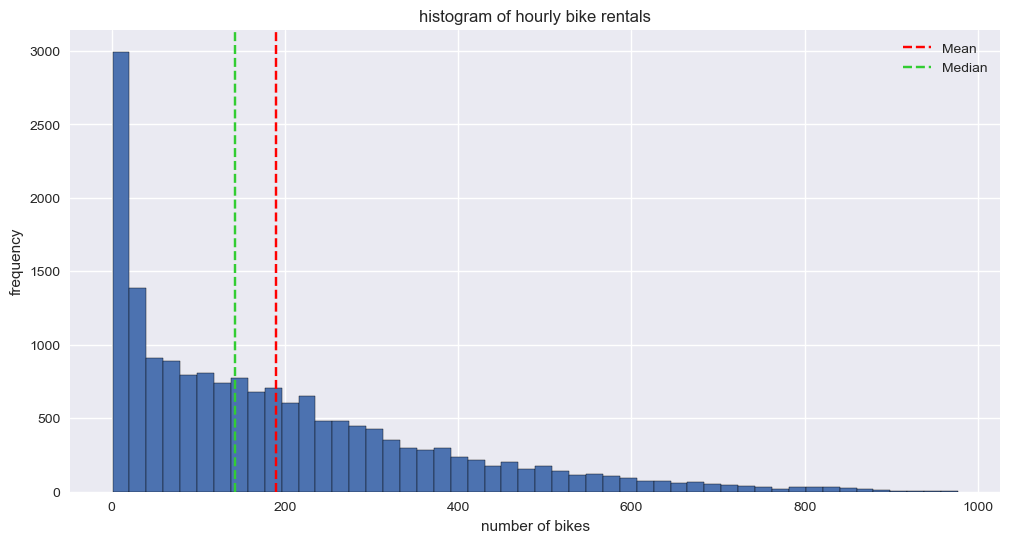

In [93]:
# plot histogram of target, bike count
plt.figure(figsize=(12,6)) 
plt.hist(df['cnt'], bins=50, edgecolor='black')  
plt.axvline(df['cnt'].mean(),color='red',linestyle='--',label='Mean')
plt.axvline(df['cnt'].median(),color='limegreen',linestyle='--',label='Median')
plt.xlabel('number of bikes')
plt.ylabel('frequency')  
plt.title('histogram of hourly bike rentals') 
plt.legend()
# plt.tight_layout() 
plt.show()  

Hourly bike rentals tend to occur in low numbers in the majority of cases, with fewer, rarer instances where large numbers of bikes are demanded. This makes the data follow a log distribution, and leads the overinflation in the mean, as it gets pushed up by high-count cases. We might anticipate applying a log transformation in a model. And we can preview it on a log scale in the below plot: 

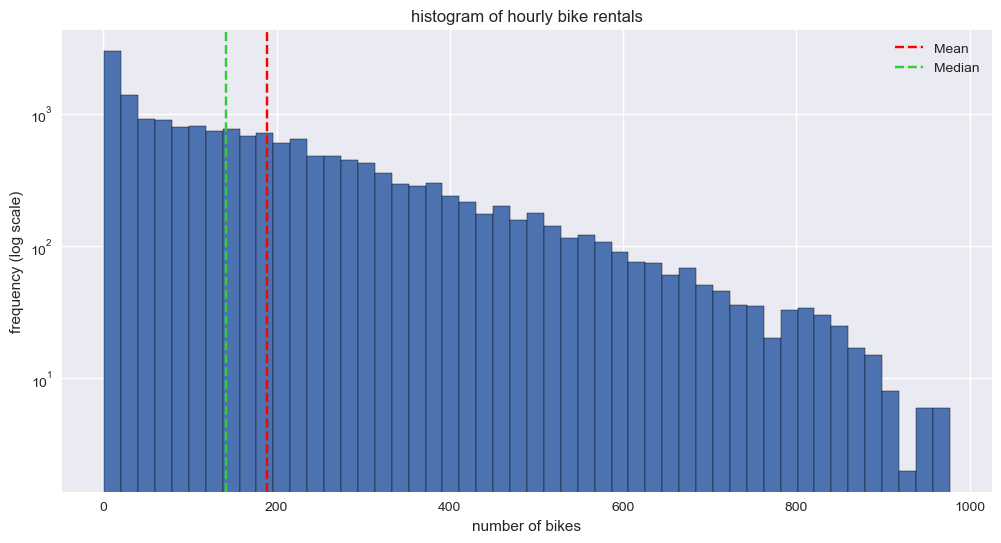

In [94]:
plt.figure(figsize=(12,6)) 
plt.hist(df['cnt'], bins=50, edgecolor='black')  
plt.axvline(df['cnt'].mean(), color='red', linestyle='--', label='Mean')
plt.axvline(df['cnt'].median(), color='limegreen', linestyle='--', label='Median')
plt.yscale('log') 
plt.xlabel('number of bikes')
plt.ylabel('frequency (log scale)')
plt.title('histogram of hourly bike rentals')
plt.legend()
plt.show()

With the transformed y-axis, we can see more clearly the relative differences in the number of hours where higher rental counts occurred. 

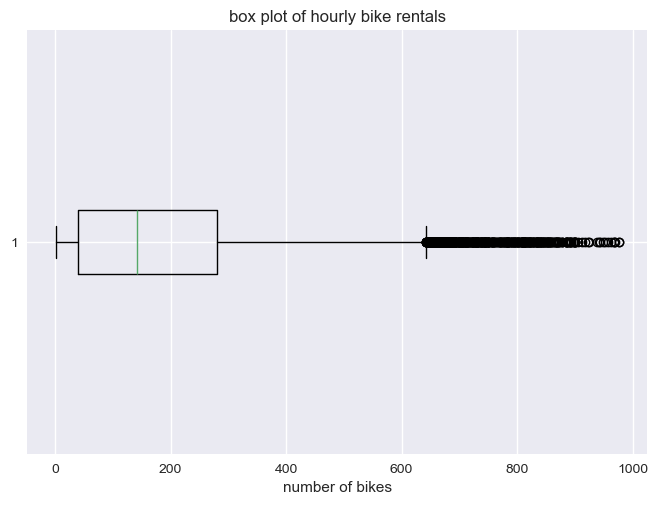

In [98]:
# boxplot of target variable
plt.plot(figsize=(6,4))
plt.boxplot(df['cnt'], vert=False)
plt.xlabel('number of bikes')
plt.title('box plot of hourly bike rentals')
plt.show()

For the majority of hours, rentals fall between 50 and just under 300 bikes (the 25th and 75th quartiles). But there are many extreme values on the upper end of the data: all of those points above the upper whisker. These could be considered outliers. These are probably real values that occur due to conditions being "just right" for rentals, like perfect weather/season/holiday status. 

### Target Variable Observations

*TODO: Write your observations here*

1. **Distribution shape:** Log
2. **Outliers:** many extreme points which could be considered outliers, even after log transformation of the target. They may likely be appropriate to keep as they may be legitimate datapoints and provide important information for the problem. We can scrutinize points more in the modeling phase by examining their leverage and influence. 
3. **Potential issues:** We may need to consider a log transformation of y and a review of points at the extreme upper end to see if they exert undue influence on model estimates.



## 4. Feature Distributions

### Feature Distribution Observations

*TODO: Write your observations here*




## 5. Correlation Analysis

### Correlation Observations

*TODO: Write your observations here*

1. **Strongest predictor:** ...
2. **Other important features:** ...
3. **Multicollinearity concerns:** ...


## 6. Key Findings Summary

## EDA Checklist

Before moving to modeling, ensure you've completed:

- [x] Loaded and examined the data
- [x] Checked data types
- [x] Identified and documented missing values
- [x] Analyzed target variable distribution
- [ ] Examined feature distributions
- [ ] Created correlation analysis
- [ ] Documented key findings
- [ ] Identified potential data quality issues